# GAN Calibration for Unified ABM: Differentiable Personalities & Market Impact

This notebook implements the GAN calibration pipeline for the 300-agent population:
- **36 Investor/Thinking Agents** (12 base frozen neural network checkpoints $\times$ 3 risk bands: `low`, `mid`, `high`)
- **100 Momentum Agents**
- **100 Value Agents**
- **64 Random Agents**

### Calibration Objectives:
1. Learn differentiable personality traits (`risk`, `fear`, `boldness`, `range_stock`) for each thinking agent, with `risk` constrained to low/mid/high bands.
2. Calibrate the aggregate market impact parameter $\eta$.
3. Use a 1D-CNN Discriminator with Feature Matching loss to align simulated return dynamics with empirical market stylized facts.
4. Export calibrated parameters to `calibrated_personalities.json` for simulation in the main ABM.

In [ ]:
# ============================================================
# CELL 0 — Imports, configuration, and reproducibility
# ============================================================
import os
import math
import random
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ---------- PATH CONFIGURATION ----------
DATA_PATH = r"C:\Users\user\.vscode\abms\abms_git\data\ADANIPORTS.csv"
CHECKPOINT_DIR = r"C:\Users\user\.vscode\abms\abms_git\checkpoint"
EXPORT_JSON_PATH = r"C:\Users\user\.vscode\abms\abms_git\calibrated_personalities.json"

# ---------- POPULATION CONFIGURATION ----------
RISK_BANDS = [('low', 0.0, 0.3), ('mid', 0.3, 0.6), ('high', 0.6, 1.0)]
N_INVESTOR_BASE = 12          # 12 base neural network checkpoints
N_INVESTORS = N_INVESTOR_BASE * len(RISK_BANDS)   # = 36
N_MOMENTUM = 100
N_VALUE = 100
N_RANDOM = 64
N_TOTAL = N_INVESTORS + N_MOMENTUM + N_VALUE + N_RANDOM  # = 300

AGENT_LOOKBACK = {'lstm': 120, 'gru': 60, 'cnn': 30, 'mlp': 45}
MAX_THINKING_LOOKBACK = max(AGENT_LOOKBACK.values())  # 120
THINKING_LOOKBACK = MAX_THINKING_LOOKBACK

USE_HARD_BAND_CLAMP = False   # False = Option A (bands as init), True = Option B (clamp every step)

# ---------- TRAINING HYPERPARAMETERS ----------
CALIB_SEQUENCE_LENGTH = 100
CALIB_EPOCHS = 200
GEN_LR = 2e-4
DISC_LR = 1e-4
FEATURE_MATCH_WEIGHT = 10.0
STARTING_CASH = 1_000_000.0
E_SCALE = 1.5
MAX_ETA = 1.0
FORECAST_TANH_SCALE = 0.5

print(f'Total Population: {N_TOTAL} ({N_INVESTORS} investors + {N_MOMENTUM} momentum + {N_VALUE} value + {N_RANDOM} random)')
print(f'Thinking Lookbacks: {AGENT_LOOKBACK} (Max = {MAX_THINKING_LOOKBACK} days)')
print(f'Risk Bands: {RISK_BANDS}')
print(f'Hard Band Clamp Enabled: {USE_HARD_BAND_CLAMP}')


Device: cpu
Total Population: 300 (36 investors + 100 momentum + 100 value + 64 random)
Thinking Lookbacks: {'lstm': 120, 'gru': 60, 'cnn': 30, 'mlp': 45} (Max = 120 days)
Risk Bands: [('low', 0.0, 0.3), ('mid', 0.3, 0.6), ('high', 0.6, 1.0)]
Hard Band Clamp Enabled: False


In [2]:
# ============================================================
# CELL 1 — Market data loading & feature construction (TS & MLP)
# ============================================================
TS_FEATURES = [
    'close_norm',
    'daily_return',
    'volume_norm',
    'vwap_distance',
    'volatility',
    'ma20_distance',
]

MLP_FEATURES = [
    'close_norm',
    'daily_return',
    'volume_norm',
    'vwap_distance',
    'momentum_15',
    'momentum_30',
    'momentum_60',
    'volatility_15',
    'volatility_30',
    'volatility_60',
]

def prepare_market_data(path):
    if not os.path.exists(path):
        alt_path = os.path.join(os.path.dirname(CHECKPOINT_DIR), 'ADANIPORTS.csv')
        if os.path.exists(alt_path):
            path = alt_path
        else:
            raise FileNotFoundError(f'Cannot find dataset at {path} or {alt_path}')
            
    df = pd.read_csv(path)
    required = ['Close', 'Volume', 'VWAP', 'Prev Close']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date')

    df = df.reset_index(drop=True).copy()
    df['daily_return'] = (df['Close'] - df['Prev Close']) / (df['Prev Close'] + 1e-12)
    df['MA20'] = df['Close'].rolling(20).mean()
    df['volatility'] = df['daily_return'].rolling(20).std()
    df['vwap_distance'] = (df['Close'] - df['VWAP']) / (df['VWAP'] + 1e-12)
    df['ma20_distance'] = (df['Close'] - df['MA20']) / (df['MA20'] + 1e-12)

    for n in (15, 30, 60):
        df[f'momentum_{n}'] = (
            (df['Close'] - df['Close'].shift(n))
            / (df['Close'].shift(n) + 1e-12)
        )
        df[f'volatility_{n}'] = df['daily_return'].rolling(n).std()

    df['log_volume'] = np.log1p(df['Volume'])
    df = df.dropna().reset_index(drop=True)

    close_mean, close_std = df['Close'].mean(), df['Close'].std()
    vol_mean, vol_std = df['log_volume'].mean(), df['log_volume'].std()

    df['close_norm'] = (df['Close'] - close_mean) / (close_std + 1e-8)
    df['volume_norm'] = (df['log_volume'] - vol_mean) / (vol_std + 1e-8)
    return df

def build_feature_matrices(df):
    return {
        'ts': df[TS_FEATURES].to_numpy(dtype=np.float32),
        'mlp': df[MLP_FEATURES].to_numpy(dtype=np.float32),
    }

MARKET_DF = prepare_market_data(DATA_PATH)
FEATURE_MATS = build_feature_matrices(MARKET_DF)
REAL_RETURNS = MARKET_DF['daily_return'].to_numpy(dtype=np.float32)
print('Market dataset prepared:', len(MARKET_DF), 'days')
print('TS Feature matrix shape :', FEATURE_MATS['ts'].shape)
print('MLP Feature matrix shape:', FEATURE_MATS['mlp'].shape)


Market dataset prepared: 2456 days
TS Feature matrix shape : (2456, 6)
MLP Feature matrix shape: (2456, 10)


In [3]:
# ============================================================
# CELL 2 — Exact architectures of the 12 base checkpoints
# ============================================================
class LSTMReturnPredictor(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=4, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            dropout=dropout, batch_first=True
        )
        self.fc1 = nn.Linear(hidden_size, 64)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        x = self.fc1(hidden[-1])
        x = self.gelu(x)
        x = self.dropout(x)
        return self.fc2(x)

class GRUReturnPredictor(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=4, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size, num_layers,
            dropout=dropout, batch_first=True
        )
        self.fc1 = nn.Linear(hidden_size, 64)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        _, hidden = self.gru(x)
        x = self.fc1(hidden[-1])
        x = self.gelu(x)
        x = self.dropout(x)
        return self.fc2(x)

class CNNReturnPredictor(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, dropout=0.5):
        super().__init__()
        channels = [input_size] + [hidden_size] * num_layers
        blocks = []
        for i in range(num_layers):
            blocks += [
                nn.Conv1d(channels[i], channels[i+1], 3, padding=1),
                nn.GroupNorm(8, channels[i+1]),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
        self.conv = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.conv(x.permute(0, 2, 1))
        x = self.pool(x).squeeze(-1)
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        return self.fc2(x)

class MLPReturnPredictor(nn.Module):
    def __init__(self, input_size=10, hidden_size=64, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x):
        return self.net(x.mean(dim=1))

print('Predictor architectures registered.')


Predictor architectures registered.


In [4]:
# ============================================================
# CELL 3 — Load and freeze the 12 base thinking checkpoints
# ============================================================
HORIZONS = (15, 30, 45)
BATCH_IDX = 1
BASE_12_CHECKPOINTS = []

def instantiate_and_load(atype, horizon):
    lb = AGENT_LOOKBACK[atype]  # lstm: 120, gru: 60, cnn: 30, mlp: 45
    if atype == 'lstm':
        model = LSTMReturnPredictor(input_size=6, hidden_size=128, num_layers=4)
    elif atype == 'gru':
        model = GRUReturnPredictor(input_size=6, hidden_size=128, num_layers=4)
    elif atype == 'cnn':
        model = CNNReturnPredictor(input_size=6, hidden_size=64, num_layers=2)
    elif atype == 'mlp':
        model = MLPReturnPredictor(input_size=10, hidden_size=64)
    
    candidates = [
        os.path.join(CHECKPOINT_DIR, f'agent_{atype}_batch_{BATCH_IDX}_{horizon}.pt'),
        os.path.join(CHECKPOINT_DIR, f'agent_{atype}_batch_{BATCH_IDX}_{horizon}.pth'),
        os.path.join(CHECKPOINT_DIR, f'best_{atype}_return_model_{horizon}.pt'),
        os.path.join(CHECKPOINT_DIR, f'best_{atype}_return_model_{horizon}.pth'),
        os.path.join(os.path.dirname(CHECKPOINT_DIR), f'best_{atype}_return_model_{horizon}.pt'),
    ]
    
    ckpt_path = None
    for cand in candidates:
        if os.path.exists(cand):
            ckpt_path = cand
            break
    
    if ckpt_path is not None:
        try:
            ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            sd = ckpt.get('model_state_dict', ckpt)
            model.load_state_dict(sd, strict=True)
            print(f'Successfully loaded {atype.upper()}-{horizon} (lookback={lb}) from {ckpt_path}')
        except Exception as e:
            print(f'Notice: Loaded with non-strict weights for {atype.upper()}-{horizon} ({e})')
            model.load_state_dict(sd, strict=False)
    else:
        print(f'Notice: Checkpoint for {atype}-{horizon} not found, using initialized weights.')
    
    model.to(DEVICE)
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    
    return {
        'type': atype,
        'horizon': horizon,
        'lookback': lb,
        'features_key': 'mlp' if atype == 'mlp' else 'ts',
        'model': model,
    }

for atype in ['lstm', 'gru', 'cnn', 'mlp']:
    for h in HORIZONS:
        BASE_12_CHECKPOINTS.append(instantiate_and_load(atype, h))

print(f'Loaded and froze {len(BASE_12_CHECKPOINTS)} base thinking models.')
print(f'Max thinking lookback: {MAX_THINKING_LOOKBACK} days')

# ------------------------------------------------------------
# Momentum and Value Signal Generators
# ------------------------------------------------------------
MOMENTUM_SIGNAL = MARKET_DF['momentum_15'].to_numpy(dtype=np.float32)
VALUE_SIGNAL = (-MARKET_DF['vwap_distance']).to_numpy(dtype=np.float32)
print('Momentum and Value signals generated.')


Successfully loaded LSTM-15 (lookback=120) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_lstm_batch_1_15.pt
Successfully loaded LSTM-30 (lookback=120) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_lstm_batch_1_30.pt
Successfully loaded LSTM-45 (lookback=120) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_lstm_batch_1_45.pt
Successfully loaded GRU-15 (lookback=60) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_gru_batch_1_15.pt
Successfully loaded GRU-30 (lookback=60) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_gru_batch_1_30.pt
Successfully loaded GRU-45 (lookback=60) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_gru_batch_1_45.pt
Successfully loaded CNN-15 (lookback=30) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_cnn_batch_1_15.pt
Successfully loaded CNN-30 (lookback=30) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_cnn_batch_1_30.pt
Successfully loaded CNN-45 (lookback=30) from C:\Users\user\.vs

In [5]:
# ============================================================
# CELL 5 — PersonalityBank & Investor Triplet Mapping (N=300)
# ============================================================
investor_checkpoint_id = []   # base checkpoint index (0..11) for each of the 36 slots
investor_band_name = []
investor_band_lo = []
investor_band_hi = []
risk_init = []

for base_id in range(N_INVESTOR_BASE):
    for band_name, lo, hi in RISK_BANDS:
        investor_checkpoint_id.append(base_id)
        investor_band_name.append(band_name)
        investor_band_lo.append(lo)
        investor_band_hi.append(hi)
        risk_init.append(random.uniform(lo, hi))

risk_bands_lo_t = torch.tensor(investor_band_lo, device=DEVICE, dtype=torch.float32)
risk_bands_hi_t = torch.tensor(investor_band_hi, device=DEVICE, dtype=torch.float32)

# Build Agent Type list for all 300 agents
AGENT_TYPES = []
for i in range(N_INVESTORS):
    base_cp = BASE_12_CHECKPOINTS[investor_checkpoint_id[i]]
    AGENT_TYPES.append(base_cp['type'])
for _ in range(N_MOMENTUM):
    AGENT_TYPES.append('momentum')
for _ in range(N_VALUE):
    AGENT_TYPES.append('value')
for _ in range(N_RANDOM):
    AGENT_TYPES.append('random')

class PersonalityBank(nn.Module):
    def __init__(self, n_total=N_TOTAL, n_investors=N_INVESTORS, risk_init_list=risk_init):
        super().__init__()
        self.n_total = n_total
        self.n_investors = n_investors
        
        # Initializations
        # 1. Risk: 36 band-constrained thinking investors + 0.5 default for others
        full_risk = list(risk_init_list) + [0.5 for _ in range(n_total - n_investors)]
        self.risk_raw = nn.Parameter(torch.tensor(full_risk, dtype=torch.float32))
        
        # 2. Fear: unconstrained uniform draw in [0.1, 0.9] for all agents
        full_fear = [random.uniform(0.1, 0.9) for _ in range(n_total)]
        self.fear = nn.Parameter(torch.tensor(full_fear, dtype=torch.float32))
        
        # 3. Boldness: in [0.5, 1.0] for thinking agents, 1.0 for others
        full_boldness = [random.uniform(0.5, 1.0) for _ in range(n_investors)] + [1.0 for _ in range(n_total - n_investors)]
        self.boldness = nn.Parameter(torch.tensor(full_boldness, dtype=torch.float32))
        
        # 4. Range stock: [5, 10] for thinking/momentum/value, [1, 5] for random agents to minimize noise impact
        stock_ranges = [random.randint(5, 10) for _ in range(n_investors + N_MOMENTUM + N_VALUE)] + [random.randint(1, 5) for _ in range(N_RANDOM)]
        self.range_stock = nn.Parameter(torch.tensor(stock_ranges, dtype=torch.float32))
        
        # 5. Market impact eta
        self.eta = nn.Parameter(torch.tensor(0.05, dtype=torch.float32))
        
        # Momentum and value sensitivities (100 each)
        self.momentum_sens = nn.Parameter(torch.randn(N_MOMENTUM) * 0.5 + 1.0)
        self.value_sens = nn.Parameter(torch.randn(N_VALUE) * 0.5 + 1.0)
        
    @property
    def risk(self):
        return torch.clamp(self.risk_raw, 1e-4, 1.0 - 1e-4)

personality_bank = PersonalityBank().to(DEVICE)
print('PersonalityBank initialized with parameters for', N_TOTAL, 'agents.')

PersonalityBank initialized with parameters for 300 agents.


In [6]:
# ============================================================
# CELL 6 — Vectorized Differentiable Rollout & 1D-CNN Discriminator
# ============================================================
class VectorizedDifferentiableABM(nn.Module):
    def __init__(self, bank, base_checkpoints, investor_checkpoint_ids):
        super().__init__()
        self.bank = bank
        self.base_checkpoints = base_checkpoints
        self.investor_checkpoint_ids = investor_checkpoint_ids
        
    def get_forecasts(self, feat_mats, t, mom_sig, val_sig):
        """Batch compute forecasts for all 300 agents at step t."""
        base_preds = []
        for cp in self.base_checkpoints:
            lb = cp['lookback']
            fkey = cp['features_key']
            w = feat_mats[fkey][t - lb + 1 : t + 1]  # (lb, 6) or (lb, 10)
            x = torch.tensor(w, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                raw = cp['model'](x).squeeze()
            base_preds.append(torch.tanh(raw * FORECAST_TANH_SCALE))
        
        forecasts = []
        # 36 Investors share base predictions via investor_checkpoint_ids
        for i in range(N_INVESTORS):
            cp_id = self.investor_checkpoint_ids[i]
            forecasts.append(base_preds[cp_id])
            
        # 100 Momentum agents
        m_val = torch.tensor(float(mom_sig[t]), device=DEVICE)
        m_preds = torch.tanh(self.bank.momentum_sens * m_val)
        for p in m_preds:
            forecasts.append(p)
            
        # 100 Value agents
        v_val = torch.tensor(float(val_sig[t]), device=DEVICE)
        v_preds = torch.tanh(self.bank.value_sens * v_val)
        for p in v_preds:
            forecasts.append(p)
            
        # 64 Random agents
        r_preds = torch.randn(N_RANDOM, device=DEVICE) * 0.5
        for p in r_preds:
            forecasts.append(p)
            
        return torch.stack(forecasts)
        
    def forward(self, feat_mats, mom_sig, val_sig, start_t, steps, initial_price):
        p_curr = torch.tensor(initial_price, device=DEVICE, dtype=torch.float32)
        sim_prices = [p_curr]
        sim_returns = []
        
        # Initialize cash & stocks for all 300 agents
        risk = self.bank.risk
        cash = torch.full((N_TOTAL,), STARTING_CASH, device=DEVICE)
        stocks = (risk * cash) / (p_curr * (1.0 - risk) + 1e-8)
        last_actions = torch.zeros(N_TOTAL, device=DEVICE)
        
        for s in range(steps):
            t = start_t + s
            f = self.get_forecasts(feat_mats, t, mom_sig, val_sig)
            
            # Equity and stock ratio
            equity = cash + stocks * p_curr
            stock_ratio = (stocks * p_curr) / (equity + 1e-8)
            e = (risk - stock_ratio) * E_SCALE
            
            # Peer influence (mean past actions)
            peer = (last_actions.mean() / (self.bank.range_stock + 1e-8)) * self.bank.fear
            
            # Continuous differentiable action
            raw = (f + e + peer) * (self.bank.boldness + 0.5)
            actions = self.bank.range_stock * torch.tanh(raw)
            
            # Update state
            last_actions = actions
            cash = cash - actions * p_curr
            stocks = stocks + actions
            
            # Price step: P_{t+1} = P_t + eta * norm_demand + noise (Normalized mean demand)
            demand = actions.mean()
            noise = torch.randn((), device=DEVICE) * 0.0015
            dp = torch.clamp(self.bank.eta * demand + noise, -0.10 * p_curr, 0.10 * p_curr)
            p_next = torch.clamp(p_curr + dp, min=1e-2)
            
            ret = torch.log((p_next + 1e-12) / (p_curr + 1e-12))
            sim_returns.append(ret)
            sim_prices.append(p_next)
            p_curr = p_next
            
        return torch.stack(sim_prices), torch.stack(sim_returns)

class ReturnDiscriminator(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, hidden_channels, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(hidden_channels, hidden_channels*2, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv1d(hidden_channels*2, hidden_channels*4, kernel_size=5, stride=2, padding=2)
        self.fc_feat = nn.Linear(hidden_channels*4, 64)
        self.fc_out = nn.Linear(64, 1)
        
    def forward(self, x):
        # x: (batch, 1, seq_len)
        h = F.leaky_relu(self.conv1(x), 0.2)
        h = F.leaky_relu(self.conv2(h), 0.2)
        h = F.leaky_relu(self.conv3(h), 0.2)
        feat = F.leaky_relu(self.fc_feat(h.mean(dim=2)), 0.2)
        out = self.fc_out(feat)
        return out, feat

diff_abm = VectorizedDifferentiableABM(personality_bank, BASE_12_CHECKPOINTS, investor_checkpoint_id).to(DEVICE)
discriminator = ReturnDiscriminator().to(DEVICE)
print('Differentiable ABM & 1D-CNN Discriminator constructed.')


Differentiable ABM & 1D-CNN Discriminator constructed.


In [7]:
# ============================================================
# CELL 7 — GAN Calibration Training Loop
# ============================================================
opt_g = torch.optim.Adam(personality_bank.parameters(), lr=GEN_LR)
opt_d = torch.optim.Adam(discriminator.parameters(), lr=DISC_LR)

bce_loss = nn.BCEWithLogitsLoss()
history = {'g_loss': [], 'd_loss': [], 'd_acc': [], 'eta': []}

START_T = THINKING_LOOKBACK
MAX_START = len(MARKET_DF) - CALIB_SEQUENCE_LENGTH - 2

print(f'Starting GAN calibration for {CALIB_EPOCHS} epochs...')

for epoch in range(CALIB_EPOCHS):
    # Sample random slice of real market returns
    t_start = random.randint(START_T, max(START_T, MAX_START))
    real_ret_slice = torch.tensor(
        REAL_RETURNS[t_start : t_start + CALIB_SEQUENCE_LENGTH],
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len)
    
    p0 = float(MARKET_DF.loc[t_start, 'Close'])
    
    # --------------------------------------------------------
    # 1. Train Discriminator
    # --------------------------------------------------------
    opt_d.zero_grad()
    
    with torch.no_grad():
        _, fake_returns = diff_abm(
            FEATURE_MATS, MOMENTUM_SIGNAL, VALUE_SIGNAL,
            t_start, CALIB_SEQUENCE_LENGTH, p0
        )
    fake_ret_slice = fake_returns.unsqueeze(0).unsqueeze(0)
    
    d_real_out, _ = discriminator(real_ret_slice)
    d_fake_out, _ = discriminator(fake_ret_slice.detach())
    
    loss_d_real = bce_loss(d_real_out, torch.ones_like(d_real_out))
    loss_d_fake = bce_loss(d_fake_out, torch.zeros_like(d_fake_out))
    loss_d = 0.5 * (loss_d_real + loss_d_fake)
    
    loss_d.backward()
    torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
    opt_d.step()
    
    # --------------------------------------------------------
    # 2. Train Generator (Thinking Agent Personalities & eta)
    # --------------------------------------------------------
    opt_g.zero_grad()
    
    _, gen_returns = diff_abm(
        FEATURE_MATS, MOMENTUM_SIGNAL, VALUE_SIGNAL,
        t_start, CALIB_SEQUENCE_LENGTH, p0
    )
    gen_ret_slice = gen_returns.unsqueeze(0).unsqueeze(0)
    
    g_fake_out, g_fake_feat = discriminator(gen_ret_slice)
    with torch.no_grad():
        _, d_real_feat = discriminator(real_ret_slice)
        
    # Feature matching loss + Adversarial loss
    loss_fm = F.mse_loss(g_fake_feat, d_real_feat)
    loss_adv = bce_loss(g_fake_out, torch.ones_like(g_fake_out))
    loss_g = loss_adv + FEATURE_MATCH_WEIGHT * loss_fm
    
    loss_g.backward()
    
    # Zero out personality gradients for non-thinking agents (personality tune happens to thinking agents only)
    with torch.no_grad():
        if personality_bank.risk_raw.grad is not None:
            personality_bank.risk_raw.grad[N_INVESTORS:].zero_()
        if personality_bank.fear.grad is not None:
            personality_bank.fear.grad[N_INVESTORS:].zero_()
        if personality_bank.boldness.grad is not None:
            personality_bank.boldness.grad[N_INVESTORS:].zero_()
        if personality_bank.range_stock.grad is not None:
            personality_bank.range_stock.grad[N_INVESTORS:].zero_()
            
    torch.nn.utils.clip_grad_norm_(personality_bank.parameters(), 1.0)
    opt_g.step()
    
    # Regularization / Clamps
    with torch.no_grad():
        personality_bank.boldness.clamp_(0.1, 2.0)
        personality_bank.range_stock[:N_INVESTORS + N_MOMENTUM + N_VALUE].clamp_(1.0, 20.0)
        personality_bank.range_stock[N_INVESTORS + N_MOMENTUM + N_VALUE:].clamp_(0.0, 5.0)
        personality_bank.eta.clamp_(1e-4, MAX_ETA)
        personality_bank.momentum_sens.clamp_(-5.0, 5.0)
        personality_bank.value_sens.clamp_(-5.0, 5.0)
        personality_bank.fear.clamp_(0.0, 1.5)
        
        if USE_HARD_BAND_CLAMP:
            personality_bank.risk_raw[:N_INVESTORS].clamp_(risk_bands_lo_t, risk_bands_hi_t)
        else:
            personality_bank.risk_raw.clamp_(1e-4, 1.0 - 1e-4)
            
    # Diagnostics
    acc_real = (torch.sigmoid(d_real_out) > 0.5).float().mean().item()
    acc_fake = (torch.sigmoid(d_fake_out) < 0.5).float().mean().item()
    d_acc = 0.5 * (acc_real + acc_fake)
    
    history['g_loss'].append(loss_g.item())
    history['d_loss'].append(loss_d.item())
    history['d_acc'].append(d_acc)
    history['eta'].append(personality_bank.eta.item())
    
    if (epoch + 1) % max(1, CALIB_EPOCHS // 10) == 0:
        print(f'Epoch {epoch+1:03d}/{CALIB_EPOCHS} | G-Loss: {loss_g.item():.4f} | D-Loss: {loss_d.item():.4f} | D-Acc: {d_acc:.2f} | Learned eta: {personality_bank.eta.item():.5f}')

print('GAN Calibration complete.')


Starting GAN calibration for 200 epochs...
Epoch 020/200 | G-Loss: 0.6926 | D-Loss: 0.6931 | D-Acc: 0.50 | Learned eta: 0.05036
Epoch 040/200 | G-Loss: 0.6933 | D-Loss: 0.6930 | D-Acc: 0.50 | Learned eta: 0.05001
Epoch 060/200 | G-Loss: 0.6932 | D-Loss: 0.6931 | D-Acc: 0.50 | Learned eta: 0.04887
Epoch 080/200 | G-Loss: 0.6930 | D-Loss: 0.6930 | D-Acc: 0.50 | Learned eta: 0.05030
Epoch 100/200 | G-Loss: 0.6931 | D-Loss: 0.6930 | D-Acc: 0.50 | Learned eta: 0.05260
Epoch 120/200 | G-Loss: 0.6926 | D-Loss: 0.6929 | D-Acc: 0.50 | Learned eta: 0.05548
Epoch 140/200 | G-Loss: 0.6936 | D-Loss: 0.6924 | D-Acc: 1.00 | Learned eta: 0.06053
Epoch 160/200 | G-Loss: 0.6921 | D-Loss: 0.6919 | D-Acc: 0.50 | Learned eta: 0.06624
Epoch 180/200 | G-Loss: 0.6973 | D-Loss: 0.6911 | D-Acc: 1.00 | Learned eta: 0.07073
Epoch 200/200 | G-Loss: 0.6958 | D-Loss: 0.6895 | D-Acc: 1.00 | Learned eta: 0.07671
GAN Calibration complete.


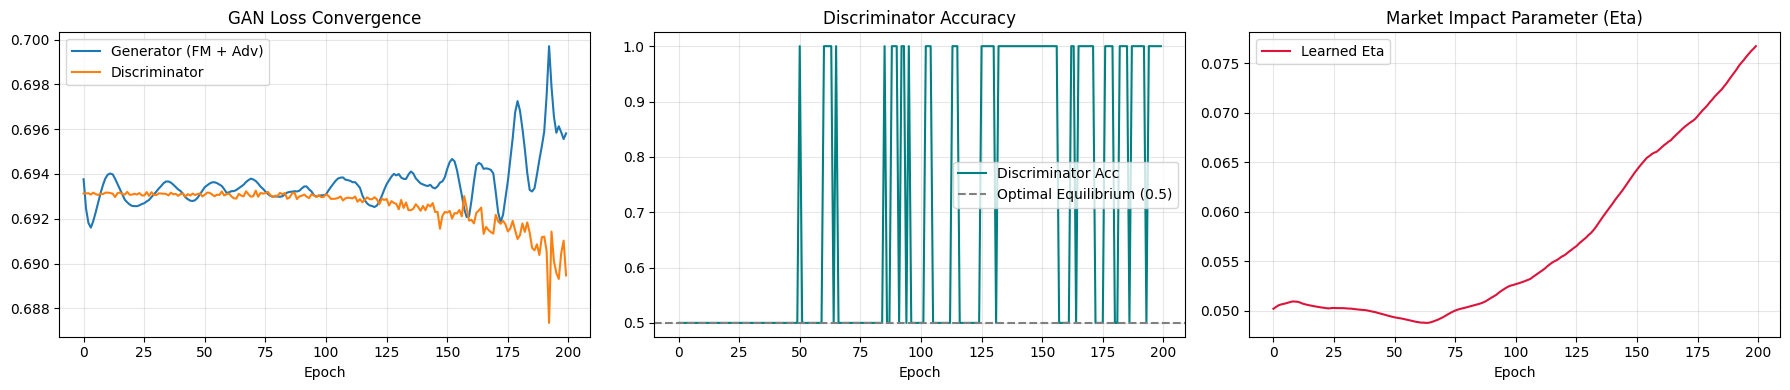

--- Stylized Facts Check ---
Real Returns Kurtosis (Fat Tails) : 1.8498
Simulated Returns Kurtosis       : -0.2636
Final Learned Eta                : 0.076706

--- Thinking Agent Calibration by Risk Band ---
Risk Band [LOW  (0.0-0.3)] (N=12): Mean Risk=0.173, Mean Fear=0.540, Mean Boldness=0.777, Mean RangeStock=8.1
Risk Band [MID  (0.3-0.6)] (N=12): Mean Risk=0.410, Mean Fear=0.446, Mean Boldness=0.780, Mean RangeStock=7.7
Risk Band [HIGH (0.6-1.0)] (N=12): Mean Risk=0.805, Mean Fear=0.504, Mean Boldness=0.753, Mean RangeStock=8.7


In [8]:
# ============================================================
# CELL 8 — Stylized Facts Validation & Risk-Band Analysis
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss curves
axes[0].plot(history['g_loss'], label='Generator (FM + Adv)')
axes[0].plot(history['d_loss'], label='Discriminator')
axes[0].set_title('GAN Loss Convergence')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Discriminator accuracy & learned eta
axes[1].plot(history['d_acc'], label='Discriminator Acc', color='teal')
axes[1].axhline(0.5, color='gray', linestyle='--', label='Optimal Equilibrium (0.5)')
axes[1].set_title('Discriminator Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history['eta'], label='Learned Eta', color='crimson')
axes[2].set_title('Market Impact Parameter (Eta)')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Stylized facts comparison on a validation rollout
with torch.no_grad():
    val_prices, val_returns = diff_abm(
        FEATURE_MATS, MOMENTUM_SIGNAL, VALUE_SIGNAL,
        START_T, min(500, len(MARKET_DF) - START_T - 1),
        float(MARKET_DF.loc[START_T, 'Close'])
    )
    
sim_ret_np = val_returns.cpu().numpy()
real_ret_np = REAL_RETURNS[START_T : START_T + len(sim_ret_np)]

# Excess kurtosis (fat tails)
from scipy.stats import kurtosis
k_real = float(kurtosis(real_ret_np))
k_sim = float(kurtosis(sim_ret_np))

print('--- Stylized Facts Check ---')
print(f'Real Returns Kurtosis (Fat Tails) : {k_real:.4f}')
print(f'Simulated Returns Kurtosis       : {k_sim:.4f}')
print(f'Final Learned Eta                : {personality_bank.eta.item():.6f}')

# Diagnostic: Group thinking agents by calibrated risk band
print('\n--- Thinking Agent Calibration by Risk Band ---')
band_stats = {'low': {'risk': [], 'fear': [], 'boldness': [], 'range_stock': []},
              'mid': {'risk': [], 'fear': [], 'boldness': [], 'range_stock': []},
              'high': {'risk': [], 'fear': [], 'boldness': [], 'range_stock': []}}

for i in range(N_INVESTORS):
    b = investor_band_name[i]
    band_stats[b]['risk'].append(personality_bank.risk[i].item())
    band_stats[b]['fear'].append(personality_bank.fear[i].item())
    band_stats[b]['boldness'].append(personality_bank.boldness[i].item())
    band_stats[b]['range_stock'].append(personality_bank.range_stock[i].item())

for b_name, lo, hi in RISK_BANDS:
    r_mean = np.mean(band_stats[b_name]['risk'])
    f_mean = np.mean(band_stats[b_name]['fear'])
    b_mean = np.mean(band_stats[b_name]['boldness'])
    rs_mean = np.mean(band_stats[b_name]['range_stock'])
    print(f'Risk Band [{b_name.upper():4s} ({lo:.1f}-{hi:.1f})] (N={len(band_stats[b_name]["risk"])}): '
          f'Mean Risk={r_mean:.3f}, Mean Fear={f_mean:.3f}, Mean Boldness={b_mean:.3f}, Mean RangeStock={rs_mean:.1f}')


In [9]:
# ============================================================
# CELL 9 — Export Calibrated Personalities JSON (N=300)
# ============================================================
os.makedirs(os.path.dirname(EXPORT_JSON_PATH), exist_ok=True)

agents_out = []
with torch.no_grad():
    for i in range(N_TOTAL):
        entry = {
            'id': i,
            'type': AGENT_TYPES[i],
            'risk': float(personality_bank.risk[i].item()),
            'fear': float(personality_bank.fear[i].item()),
            'boldness': float(personality_bank.boldness[i].item()),
            'range_stock': int(round(personality_bank.range_stock[i].item())),
        }
        if i < N_INVESTORS:
            entry['band'] = investor_band_name[i]
            entry['band_lo'] = investor_band_lo[i]
            entry['band_hi'] = investor_band_hi[i]
            entry['checkpoint_id'] = investor_checkpoint_id[i]
        agents_out.append(entry)

start_date = str(MARKET_DF.iloc[0]['Date'])[:10] if 'Date' in MARKET_DF.columns else '0'
end_date = str(MARKET_DF.iloc[-1]['Date'])[:10] if 'Date' in MARKET_DF.columns else str(len(MARKET_DF))

payload = {
    'meta': {
        'trained_on': f'{start_date}_to_{end_date}',
        'n_agents': N_TOTAL,
        'n_investors': N_INVESTORS,
        'n_momentum': N_MOMENTUM,
        'n_value': N_VALUE,
        'n_random': N_RANDOM,
        'risk_bands': RISK_BANDS,
        'discriminator_final_accuracy': float(history['d_acc'][-1]) if history.get('d_acc') else 0.5,
        'eta_learned': float(personality_bank.eta.item()),
    },
    'agents': agents_out,
}

with open(EXPORT_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2)

print(f'Successfully saved {len(agents_out)} calibrated personalities to {EXPORT_JSON_PATH}')


Successfully saved 300 calibrated personalities to C:\Users\user\.vscode\abms\files\calibrated_personalities.json
